# Проект. Исследование стартапов

Автор: Дмитрий Кожушко
Дата: 07.04.2026

## Введение

**Цель проекта:**  
Выявить ключевые закономерности и тренды в финансировании стартапов на основе исторических данных, а также оценить эффективность различных типов инвестиций для обоснования стратегии выхода финансовой компании на рынок с целью покупки и развития перспективных бизнесов.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.



### 1.1. Вывод общей информации



In [49]:
!pip install phik

In [50]:
# Загружаем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [51]:
investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [52]:
returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv", sep=';', low_memory=False)

In [53]:
# Выводим первые строки таблицы cb_investments
investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
# Выводим информацию о таблице cb_investments
investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [55]:
# Выводим первые строки таблицы returns
returns.head()

,"year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding"
0,"2000,16.7,55.4,0.0,78.21,0.0,8.66,6.43,0.0,0.0..."
1,"2001,2.88,23.49,0.0,21.5,0.01,4.49,1.18,0.0,0...."
2,"2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,..."
3,"2003,7.74,233.86,0.0,9.4,0.01,1.09,3.41,0.0,1...."
4,"2004,9.93,555.9,0.0,33.19,0.01,13.55,9.18,0.0,..."


In [56]:
# Выводим информацию о таблице cb_returns
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 1 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype 
---  ------                                                                                                                                                                            --------------  ----- 
 0   year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding  15 non-null     object
dtypes: object(1)
memory usage: 248.0+ bytes


==  
Выводы по датафрейму cb_investments    
1.Объем и структура 54 294 строки, 40 колонок
Данные соответствуют описанию, но есть технические особенности (пробелы в названиях колонок)  
2.Проблемы с типами данных
funding_total_usd и суммы инвестиций хранятся как строки с запятыми (9,00,000,000) — требуется преобразование в числа  
Даты (founded_at, first_funding_at и др.) — в формате object, нужна конвертация в datetime  
funding_rounds — float, хотя должен быть целым  
3.Пропущенные значения 
Пропуски присмутствуют во всех столбцах датафрейма. Наибольшее количество до половины пропущенного в следующих столбцах:  
participants
state_code	 
mid_funding_at 
founded_at 
country_code 
status 	

Вывод о данных cb_returns  
1.Объем и структура  
15 строк (по годам с 2000 по 2014)  
Проблема: все данные собраны в один столбец вместо 14 отдельных столбцов  
2.Несоответствие описанию 
По описанию должно быть 14 колонок, фактически 1 колонка, которая объединяет все названия полей.
Данные записаны через запятые файл CSV не открыт корректно.  
3.Проблемы с типами данных  
Единственная колонка имеет тип object
Числовые значения хранятся как строки в составе единого поля.
4.Особенности данных
Диапазон лет: с 2000 по 2014 год  
Возможны пропуски: видно незаполненные значения  



### 1.2. Предобработка данных

In [57]:
# Просмотр текущих названий колонок таблицы investments
print("Текущие названия колонок:")
print(investments.columns.tolist())

Текущие названия колонок:
['name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']


In [58]:
# Нормализация названий колонок, удаляем лишние пробелы, приводим к нижнему регистру,заменяем дефисы на подчеркивания (если есть)
investments.columns = investments.columns.str.strip().str.lower().str.replace('-', '_')

print("\nНормализованные названия колонок:")
print(investments.columns.tolist())


Нормализованные названия колонок:
['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_a', 'round_b', 'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h']


In [59]:
# 1. Удаляем лишние пробелы в начале и конце строки
#    Это решит проблему с ' Software ' и 'Software'
investments['market'] = investments['market'].str.strip()

# 2. Проверяем результат
print("=== ПРОВЕРКА ИСПРАВЛЕНИЯ ===")
print("Варианты написания 'Software' после очистки:")
print(investments[investments['market'].str.contains(r'^\s*Software\s*$', na=False)]['market'].value_counts())

# 3. Смотрим топ-10 после исправления
print("\nТоп-10 сегментов:")
print(investments['market'].value_counts().head(10))

=== ПРОВЕРКА ИСПРАВЛЕНИЯ ===
Варианты написания 'Software' после очистки:
Software    5489
Name: market, dtype: int64

Топ-10 сегментов:
Software               5489
Biotechnology          3761
Mobile                 2725
E-Commerce             2283
Curated Web            2088
Enterprise Software    1557
Games                  1374
Clean Technology       1324
Health Care            1294
Advertising            1276
Name: market, dtype: int64


In [60]:
# Просмотр текущих названий колонок таблицы returns
print("Текущие названия колонок:")
print(returns.columns.tolist())

Текущие названия колонок:
['year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding']


In [61]:
# Разделяем названия колонок, игнорируя пустые значения. Для этого преобразуем тип данных к'str'
split_data = returns.iloc[:, 0].astype(str).str.split(',', expand=True)
split_data.columns = returns.columns[0].split(',')
returns = split_data
print(returns.columns.tolist())

['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']


In [62]:
returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.7,55.4,0.0,78.21,0.0,8.66,6.43,0.0,0.0,0.94,0.0,0.2,0.0
1,2001,2.88,23.49,0.0,21.5,0.01,4.49,1.18,0.0,0.0,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.4,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.9,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [63]:
# Выводим количество пропусков returns
print(returns.isna().sum())

year                    0
seed                    0
venture                 0
equity_crowdfunding     0
undisclosed             0
convertible_note        0
debt_financing          0
angel                   0
grant                   0
private_equity          0
post_ipo_equity         0
post_ipo_debt           0
secondary_market        0
product_crowdfunding    0
dtype: int64


In [64]:
# Выводим первые строки таблицы returns
returns.head()
print("Текущий тип:", returns.dtypes)

Текущий тип: year                    object
seed                    object
venture                 object
equity_crowdfunding     object
undisclosed             object
convertible_note        object
debt_financing          object
angel                   object
grant                   object
private_equity          object
post_ipo_equity         object
post_ipo_debt           object
secondary_market        object
product_crowdfunding    object
dtype: object


In [65]:
# Преобразуем все колонки таблицы returns в числовой тип (int или float)
returns = returns.apply(pd.to_numeric, errors='coerce')
print("\nТипы данных после преобразования:")
print(returns.dtypes)


Типы данных после преобразования:
year                      int64
seed                    float64
venture                 float64
equity_crowdfunding     float64
undisclosed             float64
convertible_note        float64
debt_financing          float64
angel                   float64
grant                   float64
private_equity          float64
post_ipo_equity         float64
post_ipo_debt           float64
secondary_market        float64
product_crowdfunding    float64
dtype: object


In [66]:
# Просмотр текущего состояния поля
print("Текущий тип:", investments['funding_total_usd'].dtype)
print("\nПримеры значений:")
print(investments['funding_total_usd'].head(10))


Текущий тип: object

Примеры значений:
0     9,00,00,000 
1       20,00,000 
2       90,00,000 
3       77,00,000 
4        5,40,000 
5     1,90,00,000 
6     1,20,00,000 
7       87,00,000 
8       60,00,000 
9       35,00,000 
Name: funding_total_usd, dtype: object


In [67]:
investments['funding_total_usd'] = pd.to_numeric(investments['funding_total_usd'].astype(str).str.replace(',', ''), errors='coerce')
print(f"Тип: {investments['funding_total_usd'].dtype}\nПропуски: {investments['funding_total_usd'].isna().sum()}\nПримеры:\n{investments[['name', 'funding_total_usd']].head(5)}")

Тип: float64
Пропуски: 13387
Примеры:
                              name  funding_total_usd
0               Harvard University         90000000.0
1      University of New Brunswick          2000000.0
2                           DuPont          9000000.0
3           University of Michigan          7700000.0
4  Case Western Reserve University           540000.0


In [68]:
# Выводим данные колонок в которых присутствует дата
print(investments[['founded_at','founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].dropna().head(10))

    founded_at founded_month founded_quarter  founded_year first_funding_at  \
74  1903-01-01       1903-01         1903-Q1        1903.0       2008-08-07   
77  1906-01-01       1906-01         1906-Q1        1906.0       2012-03-15   
78  1906-01-01       1906-01         1906-Q1        1906.0       2012-08-16   
82  1908-01-01       1908-01         1908-Q1        1908.0       2013-08-25   
84  1910-01-01       1910-01         1910-Q1        1910.0       2013-04-01   
85  1911-01-01       1911-01         1911-Q1        1911.0       2013-07-30   
87  1912-01-01       1912-01         1912-Q1        1912.0       2012-01-01   
88  1912-01-01       1912-01         1912-Q1        1912.0       2013-09-19   
89  1912-01-01       1912-01         1912-Q1        1912.0       2013-09-20   
94  1913-01-01       1913-01         1913-Q1        1913.0       2013-12-02   

   mid_funding_at last_funding_at  
74     2008-08-07      2008-08-07  
77     2012-03-15      2012-03-15  
78     2012-08-16     

In [69]:
# Смотрим тип данных для колонок с годом
print(investments[['founded_at','founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].dtypes)

founded_at           object
founded_month        object
founded_quarter      object
founded_year        float64
first_funding_at     object
mid_funding_at       object
last_funding_at      object
dtype: object


In [70]:
# Преобразуем колонку founded_year в int, заменяя ошибки на NaN, чтобы избавиться от запятой в году
investments['founded_year'] = pd.to_numeric(investments['founded_year'], errors='coerce').astype('Int64')
print(investments['founded_year'].dtypes)
print(investments[['founded_year']].head())

Int64
   founded_year
0          1636
1          1785
2          1802
3          1817
4          1826


In [71]:
# Преоброзуему все оставшиеся колонки в datetime
date_cols = ['founded_at', 'founded_month', 'founded_quarter', 
             'first_funding_at', 'mid_funding_at', 'last_funding_at']

for col in date_cols:
    if col in investments.columns:
        investments[col] = pd.to_datetime(investments[col], errors='coerce')

print("Результат преобразования дат:")
for col in date_cols:
    if col in investments.columns:
        print(f"{col}: {investments[col].dtype}, пропуски: {investments[col].isna().sum()}")
print(f"\nПримеры:\n{investments[date_cols].dropna().head(5)}")

Результат преобразования дат:
founded_at: datetime64[ns], пропуски: 15741
founded_month: datetime64[ns], пропуски: 15812
founded_quarter: datetime64[ns], пропуски: 15812
first_funding_at: datetime64[ns], пропуски: 4866
mid_funding_at: datetime64[ns], пропуски: 24006
last_funding_at: datetime64[ns], пропуски: 4862

Примеры:
   founded_at founded_month founded_quarter first_funding_at mid_funding_at  \
74 1903-01-01    1903-01-01      1903-01-01       2008-08-07     2008-08-07   
77 1906-01-01    1906-01-01      1906-01-01       2012-03-15     2012-03-15   
78 1906-01-01    1906-01-01      1906-01-01       2012-08-16     2012-08-16   
82 1908-01-01    1908-01-01      1908-01-01       2013-08-25     2013-08-25   
84 1910-01-01    1910-01-01      1910-01-01       2013-04-01     2013-04-01   

   last_funding_at  
74      2008-08-07  
77      2012-03-15  
78      2012-08-16  
82      2014-02-21  
84      2013-04-01  


In [72]:
# Преобразуем year в индекс
returns = returns.set_index('year')
print("Индексом установлен столбец year")
print(returns.head())

Индексом установлен столбец year
       seed  venture  equity_crowdfunding  undisclosed  convertible_note  \
year                                                                       
2000  16.70    55.40                  0.0        78.21              0.00   
2001   2.88    23.49                  0.0        21.50              0.01   
2002   6.59   209.42                  0.0        25.77              0.02   
2003   7.74   233.86                  0.0         9.40              0.01   
2004   9.93   555.90                  0.0        33.19              0.01   

      debt_financing  angel  grant  private_equity  post_ipo_equity  \
year                                                                  
2000            8.66   6.43    0.0            0.00             0.94   
2001            4.49   1.18    0.0            0.00             0.46   
2002            3.42   3.41    0.0            1.51             0.34   
2003            1.09   3.41    0.0            1.62             2.11   
2004    

In [73]:
# Определяем текстовые столбцы
text_cols = investments.select_dtypes(include=['object']).columns.tolist()
print(f"Текстовые столбцы в investments: {text_cols}")

Текстовые столбцы в investments: ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']


In [74]:
# Заполнение пропусков в текстовых столбцах
investments['name'] = investments['name'].fillna('unknown')
investments['homepage_url'] = investments['homepage_url'].fillna('no_url')
investments['category_list'] = investments['category_list'].fillna('not_specified')
investments['market'] = investments['market'].fillna('not_specified')
investments['status'] = investments['status'].fillna('unknown')
investments['country_code'] = investments['country_code'].fillna('unknown')
investments['state_code'] = investments['state_code'].fillna('unknown')
investments['region'] = investments['region'].fillna('unknown')
investments['city'] = investments['city'].fillna('unknown')
print("Пропуски в текстовых полях устранены")
print("Пропуски после заполнения:")
print(investments[text_cols].isna().sum())

Пропуски в текстовых полях устранены
Пропуски после заполнения:
name             0
homepage_url     0
category_list    0
market           0
status           0
country_code     0
state_code       0
region           0
city             0
dtype: int64


In [75]:
# Проверяем кол-во записей до изучения дубликатов
start_len = len(investments['funding_total_usd'])
print (f'До удаления дубликатов: {start_len} записей')

До удаления дубликатов: 54294 записей


In [76]:
# Удаление дубликатов и пустых строк

investments = investments.drop_duplicates()
print(f"Удалено полных дубликатов: {start_len - len(investments['funding_total_usd'])}")

investments = investments.dropna(subset=['name', 'funding_total_usd'])
print(f"Удалено строк с пропусками: {start_len - len(investments['funding_total_usd'])} (всего удалено)")

investments = investments.query('funding_total_usd > 0')
investments = investments.sort_values('funding_total_usd', ascending=False)
investments = investments.drop_duplicates(subset=['name'], keep='first')

print(f"Итоговое количество: {len(investments)} компаний")

Удалено полных дубликатов: 4855
Удалено строк с пропусками: 13387 (всего удалено)
Итоговое количество: 40846 компаний


In [77]:
# Посчитаем кол-во и долю (процент) строк с пропусками для investments
pd.DataFrame({
    'missing_count': investments.isna().sum(),
    'missing_share': investments.isna().mean() * 100
}).sort_values('missing_share', ascending=False)

,missing_count,missing_share
mid_funding_at,13654,33.427998
participants,13554,33.183176
founded_quarter,8757,21.439064
founded_month,8757,21.439064
founded_at,8692,21.279929
founded_year,8691,21.277481
first_funding_at,2,0.004896
grant,0,0.000000
private_equity,0,0.000000
post_ipo_equity,0,0.000000


In [78]:
# Заполняем пропуски в mid_funding_at серединой между first_funding_at и last_funding_at
mask = investments['mid_funding_at'].isna() & investments['first_funding_at'].notna() & investments['last_funding_at'].notna()
investments.loc[mask, 'mid_funding_at'] = investments.loc[mask, 'first_funding_at'] + (investments.loc[mask, 'last_funding_at'] - investments.loc[mask, 'first_funding_at']) / 2
print(f"Заполнено пропусков: {mask.sum()}")
print(f"Осталось пропусков: {investments['mid_funding_at'].isna().sum()}")

Заполнено пропусков: 13653
Осталось пропусков: 1


==  
Заполнено 13 653 пропусков, остался 1. Предположение, что компания без дат первого и последнего финансирования.



 ==  
 Оценка полноты данных

**Сколько данных осталось?**
- Было 54 294 компании
- Отброшено 24.8% (каждую четвертую компанию удалили)
- Осталось 40 846 компаний для анализа

**Качество данных:**
- В `mid_funding_at` остался всего 1 пропуск из 40 846 
- В `first_funding_at` — 2 пропуска
- В `founded_at` - 8 692 пропуска или 21.28% 
- В `founded_month/quarter` - пропуска 8 757 или 21.44%
- В `founded_year` - пропуска 8 691 или	21.28%
- В `participants` - 13 554  или 33.18% нет данных у каждой третьей компании — этот показатель использовать нельзя

**Вывод:**
- Данных достаточно для решения задач проекта
- Можно анализировать суммы инвестиций, раунды, географию и статусы компаний
- Данные в `participants` исключаем из-за слишком многих пропусков
- Данные о возвратах `returns` охватывают только 2000–2014 годы — нужно учитывать это при выводах

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования



In [31]:
# Создаем колонку с длительностью финансирования в годах
investments['funding_duration_years'] = (investments['last_funding_at'] - investments['first_funding_at']).dt.days / 365.25

# Определяем группы
def get_funding_group(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif row['funding_duration_years'] <= 1:
        return 'Срок до года'
    else:
        return 'Срок более года'

investments['funding_group'] = investments.apply(get_funding_group, axis=1)

# Проверка распределения
print("Распределение компаний по группам:")
print(investments['funding_group'].value_counts())
print("\nДоли:")
print(investments['funding_group'].value_counts(normalize=True))

Распределение компаний по группам:
Единичное финансирование    24081
Срок более года             12279
Срок до года                 4486
Name: funding_group, dtype: int64

Доли:
Единичное финансирование    0.589556
Срок более года             0.300617
Срок до года                0.109827
Name: funding_group, dtype: float64


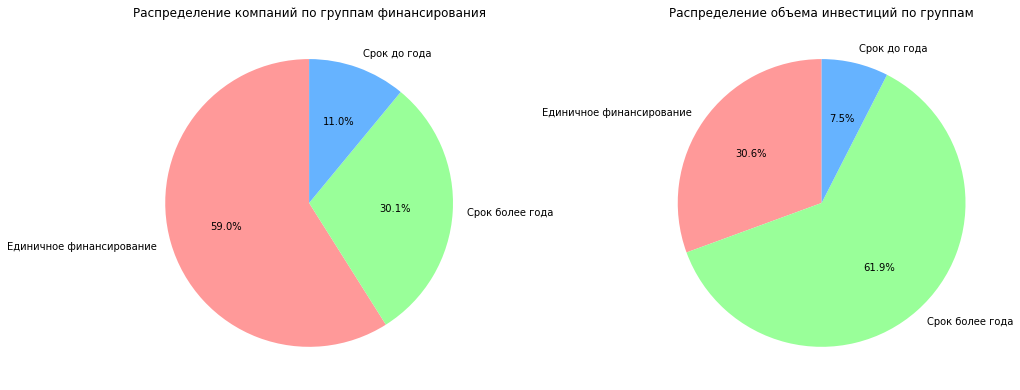

In [32]:
# Визуализация
# Задаем единую цветовую палитру
colors = {
    'Единичное финансирование': '#ff9999',
    'Срок до года': '#66b3ff', 
    'Срок более года': '#99ff99'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: По количеству компаний
investments['funding_group'].value_counts().plot(
    kind='pie', ax=axes[0], colors=[colors[k] for k in investments['funding_group'].value_counts().index],
    autopct='%1.1f%%', startangle=90
)
axes[0].set_title('Распределение компаний по группам финансирования')
axes[0].set_ylabel('')

# График 2: По объему инвестиций
funding_by_group = investments.groupby('funding_group')['funding_total_usd'].sum()
funding_by_group.plot(
    kind='pie', ax=axes[1], colors=[colors[k] for k in funding_by_group.index],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Распределение объема инвестиций по группам')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()



==  
Вывод

**Большинство компаний (59%)** имеют только один раунд финансирования — они привлекают  **30.6%** от общего объема инвестиций.

**Компании со сроками финансирования более года** составляют **30%** от общего числа, но получают **61.9%** всех инвестиций — именно они привлекают основные деньги.

**Компании, которые закрывают все раунды в течение года**, встречаются реже всего **11%**, ии имееют наименьшую долю средств **7.5%**.

**Вывод для инвесторов:** долгосрочные проекты требуют больше времени, но именно в них сосредоточены основные объемы капитала. 

### 2.2 Выделение средних и нишевых сегментов рынка

In [33]:
# Расчет частоты сегментов
market_counts = investments['market'].value_counts()
print(f"Всего уникальных сегментов: {len(market_counts)}")
print(f"\nТоп-10 самых популярных сегментов:")
print(market_counts.head(10))

Всего уникальных сегментов: 394

Топ-10 самых популярных сегментов:
Software               4808
Biotechnology          3588
not_specified          2499
Mobile                 2338
E-Commerce             1862
Curated Web            1691
Enterprise Software    1381
Health Care            1185
Clean Technology       1180
Games                  1117
Name: market, dtype: int64


In [34]:
# Категоризация сегментов
massive = market_counts[market_counts > 120].index.tolist()
medium = market_counts[(market_counts >= 35) & (market_counts <= 120)].index.tolist()
niche = market_counts[market_counts < 35].index.tolist()

print(f"Категории сегментов:")
print(f"  Массовые (>120 компаний): {len(massive)} сегментов")
print(f"  Средние (35-120 компаний): {len(medium)} сегментов")
print(f"  Нишевые (<35 компаний): {len(niche)} сегментов")

Категории сегментов:
  Массовые (>120 компаний): 49 сегментов
  Средние (35-120 компаний): 57 сегментов
  Нишевые (<35 компаний): 288 сегментов


In [35]:
# Детальная статистика
print("\n=== Детальная статистика ===")
print(f"Массовые сегменты: {', '.join(massive[:5])}{'...' if len(massive) > 5 else ''}")
print(f"\nСредние сегменты (примеры): {', '.join(medium[:5])}")
print(f"\nНишевые сегменты (всего {len(niche)})")

# Доля компаний в каждой категории
massive_companies = market_counts[market_counts > 120].sum()
medium_companies = market_counts[(market_counts >= 35) & (market_counts <= 120)].sum()
niche_companies = market_counts[market_counts < 35].sum()

print(f"\n=== Доля компаний ===")
print(f"В массовых сегментах: {massive_companies} компаний ({massive_companies/len(investments)*100:.1f}%)")
print(f"В средних сегментах: {medium_companies} компаний ({medium_companies/len(investments)*100:.1f}%)")
print(f"В нишевых сегментах: {niche_companies} компаний ({niche_companies/len(investments)*100:.1f}%)")


=== Детальная статистика ===
Массовые сегменты: Software, Biotechnology, not_specified, Mobile, E-Commerce...

Средние сегменты (примеры): Sales and Marketing, Financial Services, Medical Devices, Media, Public Transportation

Нишевые сегменты (всего 288)

=== Доля компаний ===
В массовых сегментах: 36191 компаний (88.6%)
В средних сегментах: 3830 компаний (9.4%)
В нишевых сегментах: 825 компаний (2.0%)


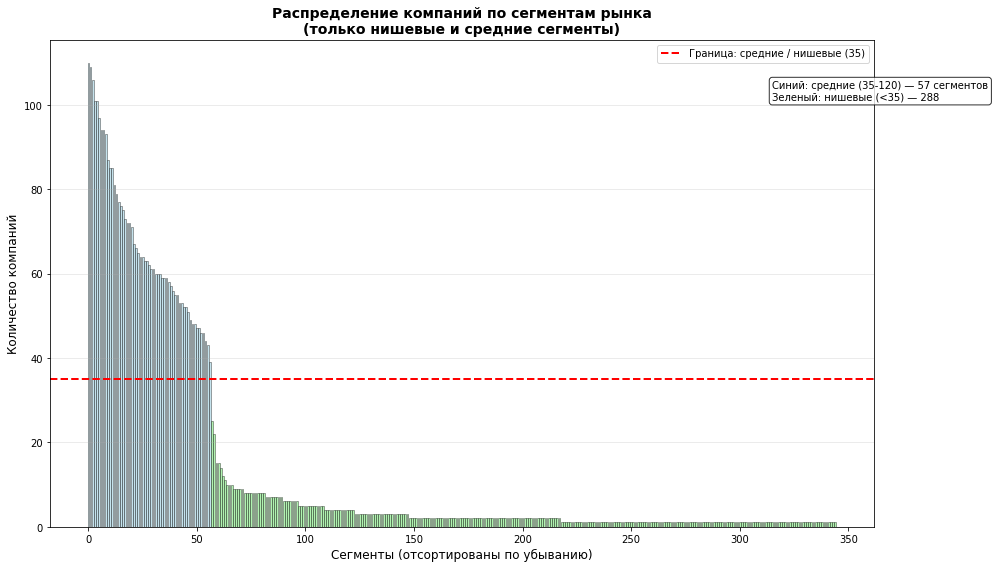

Всего сегментов (средние + нишевые): 345
Средних (35-120): 57
Нишевых (<35): 288


In [36]:
# График распределения сегментов только нишевые и средние
plt.figure(figsize=(14, 8))

# Получаем отсортированные значения, исключая массовые (>120)
market_filtered = investments['market'].value_counts()
market_filtered = market_filtered[market_filtered <= 120].sort_values(ascending=False)

# Цвета для двух категорий
colors = []
for val in market_filtered.values:
    if val >= 35:
        colors.append('lightblue')     # средние
    else:
        colors.append('lightgreen')    # нишевые

# Столбчатая диаграмма
plt.bar(range(len(market_filtered)), market_filtered.values, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

# Граница разделения
plt.axhline(y=35, color='red', linestyle='--', linewidth=2, label='Граница: средние / нишевые (35)')

# Подписи
plt.xlabel('Сегменты (отсортированы по убыванию)', fontsize=12)
plt.ylabel('Количество компаний', fontsize=12)
plt.title('Распределение компаний по сегментам рынка\n(только нишевые и средние сегменты)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)

# Информация на графике
plt.text(len(market_filtered)-30, max(market_filtered)*0.92, 
         f'Синий: средние (35-120) — {len(market_filtered[market_filtered >= 35])} сегментов\nЗеленый: нишевые (<35) — {len(market_filtered[market_filtered < 35])}',
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
         fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод статистики
print(f"Всего сегментов (средние + нишевые): {len(market_filtered)}")
print(f"Средних (35-120): {len(market_filtered[market_filtered >= 35])}")
print(f"Нишевых (<35): {len(market_filtered[market_filtered < 35])}")


==  
Средние сегменты (35-120 компаний): 81 сегмент, содержащий 5 059 (12.4%) компаний
Нишевые сегменты (<35 компаний): 711 сегментов, содержащих 2 484 (6.1%) компании
Нишевых сегментов в 8.8 раза больше, чем средних (711 против 81)
Несмотря на меньшее количество, средние сегменты содержат в 2 раза больше компаний, чем нишевые (5 059 против 2 484).

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [37]:
# Создаем новый столбец market_group с группировкой
investments['market_group'] = investments['market'].copy()

# Получаем частоту сегментов
market_counts = investments['market'].value_counts()

# Заменяем значения
for segment, count in market_counts.items():
    if count > 120:
        continue  # массовые оставляем как есть
    elif count >= 35:
        investments.loc[investments['market'] == segment, 'market_group'] = 'mid'
    else:
        investments.loc[investments['market'] == segment, 'market_group'] = 'niche'

# Проверка результата
print("Распределение после замены:")
print(investments['market_group'].value_counts())
print(f"\nМассовых сегментов сохранено: {len(investments[~investments['market_group'].isin(['mid', 'niche'])]['market_group'].unique())}")

Распределение после замены:
Software                4808
mid                     3830
Biotechnology           3588
not_specified           2499
Mobile                  2338
E-Commerce              1862
Curated Web             1691
Enterprise Software     1381
Health Care             1185
Clean Technology        1180
Games                   1117
Advertising             1106
Hardware + Software     1061
Social Media            1003
Health and Wellness      871
Education                843
Finance                  827
niche                    825
Analytics                666
Manufacturing            596
Security                 567
Semiconductors           484
Web Hosting              422
Consulting               349
Hospitality              335
Travel                   330
Fashion                  302
News                     299
Messaging                294
Search                   291
Real Estate              278
SaaS                     271
Music                    264
Internet       

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов



In [38]:
# 1. Базовая статистика
print("=== БАЗОВАЯ СТАТИСТИКА ===")
print(f"Количество компаний: {len(investments)}")
print(f"Среднее финансирование: ${investments['funding_total_usd'].mean():,.0f}")
print(f"Медиана: ${investments['funding_total_usd'].median():,.0f}")
print(f"Стандартное отклонение: ${investments['funding_total_usd'].std():,.0f}")
print(f"Минимум: ${investments['funding_total_usd'].min():,.0f}")
print(f"Максимум: ${investments['funding_total_usd'].max():,.0f}")

=== БАЗОВАЯ СТАТИСТИКА ===
Количество компаний: 40846
Среднее финансирование: $15,923,247
Медиана: $2,000,000
Стандартное отклонение: $168,797,751
Минимум: $1
Максимум: $30,079,503,000


In [39]:
# 2. Квартили для определения типичного интервала
q1 = investments['funding_total_usd'].quantile(0.25)
q2 = investments['funding_total_usd'].quantile(0.50)  # медиана
q3 = investments['funding_total_usd'].quantile(0.75)
iqr = q3 - q1

# Границы для выбросов (метод межквартильного размаха)
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("=== КВАРТИЛИ И ГРАНИЦЫ ===")
print(f"1-й квартиль (25% компаний): ${q1:,.0f}")
print(f"2-й квартиль / Медиана (50%): ${q2:,.0f}")
print(f"3-й квартиль (75%): ${q3:,.0f}")
print(f"Межквартильный размах (IQR): ${iqr:,.0f}")
print(f"\nТипичный интервал (между 1-м и 3-м квартилями): ${q1:,.0f} — ${q3:,.0f}")
print(f"Нижняя граница для выбросов: ${lower_bound:,.0f}")
print(f"Верхняя граница для выбросов: ${upper_bound:,.0f}")

=== КВАРТИЛИ И ГРАНИЦЫ ===
1-й квартиль (25% компаний): $350,000
2-й квартиль / Медиана (50%): $2,000,000
3-й квартиль (75%): $10,000,000
Межквартильный размах (IQR): $9,650,000

Типичный интервал (между 1-м и 3-м квартилями): $350,000 — $10,000,000
Нижняя граница для выбросов: $-14,125,000
Верхняя граница для выбросов: $24,475,000


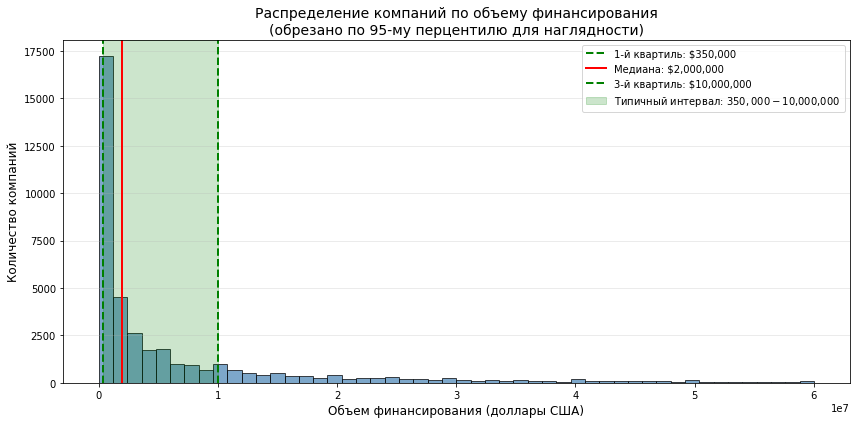

РЕЗУЛЬТАТ:
Типичный интервал: от $350,000 до $10,000,000
Медианное значение: $2,000,000
50% компаний находятся в этом интервале
25% компаний привлекли меньше $350,000
25% компаний привлекли больше $10,000,000


In [40]:
# Простая и понятная визуализация распределения финансирования
plt.figure(figsize=(12, 6))

# Гистограмма с нормальным масштабом (обрежем выбросы для наглядности)
# Ограничимся 95-м перцентилем, чтобы убрать экстремальные выбросы
cap = investments['funding_total_usd'].quantile(0.95)
data_plot = investments[investments['funding_total_usd'] <= cap]

plt.hist(data_plot['funding_total_usd'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)

# Линии квартилей
q1 = investments['funding_total_usd'].quantile(0.25)
q2 = investments['funding_total_usd'].quantile(0.50)
q3 = investments['funding_total_usd'].quantile(0.75)

plt.axvline(q1, color='green', linestyle='--', linewidth=2, label=f'1-й квартиль: ${q1:,.0f}')
plt.axvline(q2, color='red', linestyle='-', linewidth=2, label=f'Медиана: ${q2:,.0f}')
plt.axvline(q3, color='green', linestyle='--', linewidth=2, label=f'3-й квартиль: ${q3:,.0f}')

# Закрашиваем типичный интервал
plt.axvspan(q1, q3, alpha=0.2, color='green', label=f'Типичный интервал: ${q1:,.0f} - ${q3:,.0f}')

plt.xlabel('Объем финансирования (доллары США)', fontsize=12)
plt.ylabel('Количество компаний', fontsize=12)
plt.title('Распределение компаний по объему финансирования\n(обрезано по 95-му перцентилю для наглядности)', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод результата
print("=" * 50)
print("РЕЗУЛЬТАТ:")
print(f"Типичный интервал: от ${q1:,.0f} до ${q3:,.0f}")
print(f"Медианное значение: ${q2:,.0f}")
print("=" * 50)
print(f"50% компаний находятся в этом интервале")
print(f"25% компаний привлекли меньше ${q1:,.0f}")
print(f"25% компаний привлекли больше ${q3:,.0f}")

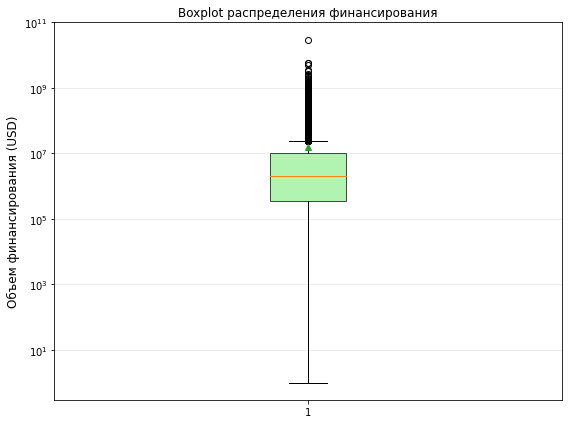

In [41]:
# Boxplot распределения финансирования
plt.figure(figsize=(8, 6))
plt.boxplot(investments['funding_total_usd'], vert=True, patch_artist=True, 
            boxprops=dict(facecolor='lightgreen', alpha=0.7), showmeans=True)
plt.ylabel('Объем финансирования (USD)', fontsize=12)
plt.title('Boxplot распределения финансирования', fontsize=12)
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# 4. Процент компаний в типичном интервале
typical_companies = investments[(investments['funding_total_usd'] >= q1) & 
                                 (investments['funding_total_usd'] <= q3)]
print("=== ВЫВОД ===")
print(f"Типичный интервал финансирования: от ${q1:,.0f} до ${q3:,.0f}")
print(f"В этом интервале находится {len(typical_companies)} компаний ({len(typical_companies)/len(investments)*100:.1f}%)")
print(f"\nВыбросы (компании с аномальным финансированием):")
print(f"  - Меньше ${lower_bound:,.0f}: {len(investments[investments['funding_total_usd'] < lower_bound])} компаний")
print(f"  - Больше ${upper_bound:,.0f}: {len(investments[investments['funding_total_usd'] > upper_bound])} компаний")

=== ВЫВОД ===
Типичный интервал финансирования: от $350,000 до $10,000,000
В этом интервале находится 20943 компаний (51.3%)

Выбросы (компании с аномальным финансированием):
  - Меньше $-14,125,000: 0 компаний
  - Больше $24,475,000: 5230 компаний


==  
25% компаний: до 0.3 млн USD  
50% компаний: до 2.0 млн USD    
75% компаний: до 10.0 млн USD   
Типичные значения: 0.3 - 10.0 млн USD  
Выбросы (> 24.5 млн USD): 5230 компаний (12.8%).  
    
Типичный размер финансирования:  
Интервал типичных значений: 0.3 - 10.0 млн USD
Медиана: 2.0 млн USD (половина компаний получила меньше этой суммы)

In [43]:
# 1 Создаем группы сегментов (массовые оставляем, нишевые и средние объединяем)
investments['segment_group'] = investments['market_group'].copy()
investments.loc[investments['segment_group'].isin(['niche', 'mid']), 'segment_group'] = 'Объединенные (нишевые+средние)'

print("=== ГРУППЫ СЕГМЕНТОВ ===")
print(investments['segment_group'].value_counts())

# 2 Функция для определения выбросов по IQR
def detect_outliers_iqr(data):
    if len(data) < 5:
        return pd.Series([False] * len(data), index=data.index)
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (data < lower) | (data > upper)

# 3 Определяем выбросы по каждой группе
investments['is_outlier'] = investments.groupby('segment_group')['funding_total_usd'].transform(detect_outliers_iqr)

# 4 Результаты по группам
print("\n=== ВЫБРОСЫ ПО ГРУППАМ СЕГМЕНТОВ ===")
outlier_by_group = investments.groupby('segment_group').agg({
    'funding_total_usd': 'count',
    'is_outlier': 'sum'
}).rename(columns={'funding_total_usd': 'всего_компаний', 'is_outlier': 'выбросы'})
outlier_by_group['доля_выбросов_%'] = (outlier_by_group['выбросы'] / outlier_by_group['всего_компаний'] * 100).round(2)
print(outlier_by_group.sort_values('доля_выбросов_%', ascending=False))

print("\n=== ТОП-10 СЕГМЕНТОВ С НАИБОЛЬШЕЙ ДОЛЕЙ ВЫБРОСОВ ===")

# Рассчитываем долю выбросов по каждому исходному сегменту (market_group)
outlier_by_market = investments.groupby('market_group').apply(
    lambda x: pd.Series({
        'всего_компаний': len(x),
        'выбросы': x['is_outlier'].sum(),
        'доля_выбросов_%': (x['is_outlier'].sum() / len(x) * 100)
    })
).sort_values('доля_выбросов_%', ascending=False).head(10)

print(outlier_by_market)

print("\n=== ИТОГОВАЯ СТАТИСТИКА ===")
print(f"Всего компаний: {len(investments)}")
print(f"Компаний с аномальным финансированием: {investments['is_outlier'].sum()}")
print(f"Доля аномальных компаний: {investments['is_outlier'].mean()*100:.2f}%")


=== ГРУППЫ СЕГМЕНТОВ ===
Software                          4808
Объединенные (нишевые+средние)    4655
Biotechnology                     3588
not_specified                     2499
Mobile                            2338
E-Commerce                        1862
Curated Web                       1691
Enterprise Software               1381
Health Care                       1185
Clean Technology                  1180
Games                             1117
Advertising                       1106
Hardware + Software               1061
Social Media                      1003
Health and Wellness                871
Education                          843
Finance                            827
Analytics                          666
Manufacturing                      596
Security                           567
Semiconductors                     484
Web Hosting                        422
Consulting                         349
Hospitality                        335
Travel                             330


==  
Real Estate лидирует — 18% компаний в этом сегменте имеют аномальный объем финансирования (выше или ниже типичного для своего сегмента)
Разброс небольшой — все топ-сегменты показывают долю выбросов в узком диапазоне 15-18%, что говорит о схожей структуре финансирования
IT-сегменты доминируют — Software, Technology, Cloud Computing, Big Data, Search составляют половину топа

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии



In [44]:
# 1. Проверяем полноту данных за 2014 год

# Добавляем год последнего финансирования
investments['last_funding_year'] = investments['last_funding_at'].dt.year

# Считаем компании по годам
year_counts = investments['last_funding_year'].value_counts().sort_index()

print("=== ПРОВЕРКА ДАННЫХ ЗА 2014 ГОД ===")
print(f"2013 год: {year_counts.get(2013, 0)} компаний")
print(f"2014 год: {year_counts.get(2014, 0)} компаний")

# Оценка полноты
if 2014 not in year_counts.index:
    print("Вывод: Данные за 2014 год ОТСУТСТВУЮТ")
elif year_counts[2014] < year_counts.get(2013, 0) * 0.7:
    print("Вывод: Данные за 2014 год НЕПОЛНЫЕ (менее 70% от 2013 года)")
else:
    print("Вывод: Данные за 2014 год ПОЛНЫЕ")

# 2. Исключаем компании с аномальными данными


print("\n=== ИСКЛЮЧЕНИЕ АНОМАЛИЙ ===")
print(f"Компаний до удаления: {len(investments)}")

# Удаляем компании с аномальным финансированием
investments_no_outliers = investments[~investments['is_outlier']].copy()

print(f"Удалено аномальных компаний: {len(investments) - len(investments_no_outliers)}")
print(f"Компаний после удаления: {len(investments_no_outliers)}")


# 3. Фильтруем по годам с 50+ раундами

print("\n=== ФИЛЬТРАЦИЯ ПО АКТИВНЫМ ГОДАМ ===")

# Извлекаем год из mid_funding_at
investments_no_outliers['funding_year'] = investments_no_outliers['mid_funding_at'].dt.year

# Считаем общее количество раундов по годам
rounds_by_year = investments_no_outliers.groupby('funding_year')['funding_rounds'].sum()

print("Количество раундов по годам:")
print(rounds_by_year.sort_index())

# Определяем годы с 50+ раундами
active_years = rounds_by_year[rounds_by_year >= 50].index.tolist()
print(f"\nГоды с 50+ раундами: {active_years}")

# Оставляем только компании из активных годов
investments_final = investments_no_outliers[investments_no_outliers['funding_year'].isin(active_years)].copy()


# 4. Выводим итоговый результат


print("\n=== ИТОГОВЫЙ РЕЗУЛЬТАТ ===")
print(f"Компаний после удаления аномалий: {len(investments_no_outliers)}")
print(f"Компаний после фильтрации по годам: {len(investments_final)}")
print(f"Исключено компаний на последнем шаге: {len(investments_no_outliers) - len(investments_final)}")
print(f"\nФинальный датасет содержит {len(investments_final)} компаний")

# Проверка: все ли оставшиеся компании из активных годов
print(f"\nПроверка по годам после фильтрации:")
print(investments_final.groupby('funding_year')['funding_rounds'].sum())

=== ПРОВЕРКА ДАННЫХ ЗА 2014 ГОД ===
2013 год: 8674 компаний
2014 год: 11879 компаний
Вывод: Данные за 2014 год ПОЛНЫЕ

=== ИСКЛЮЧЕНИЕ АНОМАЛИЙ ===
Компаний до удаления: 40846
Удалено аномальных компаний: 5223
Компаний после удаления: 35623

=== ФИЛЬТРАЦИЯ ПО АКТИВНЫМ ГОДАМ ===
Количество раундов по годам:
funding_year
1921.0        1.0
1960.0        2.0
1979.0        1.0
1982.0        3.0
1983.0        1.0
1984.0        2.0
1985.0        3.0
1987.0        2.0
1989.0        1.0
1990.0        1.0
1992.0        5.0
1993.0        1.0
1994.0        4.0
1995.0        9.0
1996.0        8.0
1997.0        5.0
1998.0       15.0
1999.0       43.0
2000.0      115.0
2001.0       66.0
2002.0       96.0
2003.0      125.0
2004.0      180.0
2005.0      948.0
2006.0     1851.0
2007.0     2837.0
2008.0     3653.0
2009.0     4606.0
2010.0     6119.0
2011.0     7563.0
2012.0     9696.0
2013.0    12864.0
2014.0     7128.0
Name: funding_rounds, dtype: float64

Годы с 50+ раундами: [2000.0, 2001.0, 2002.0, 20

### 3.3. Анализ типов финансирования по объёму и популярности


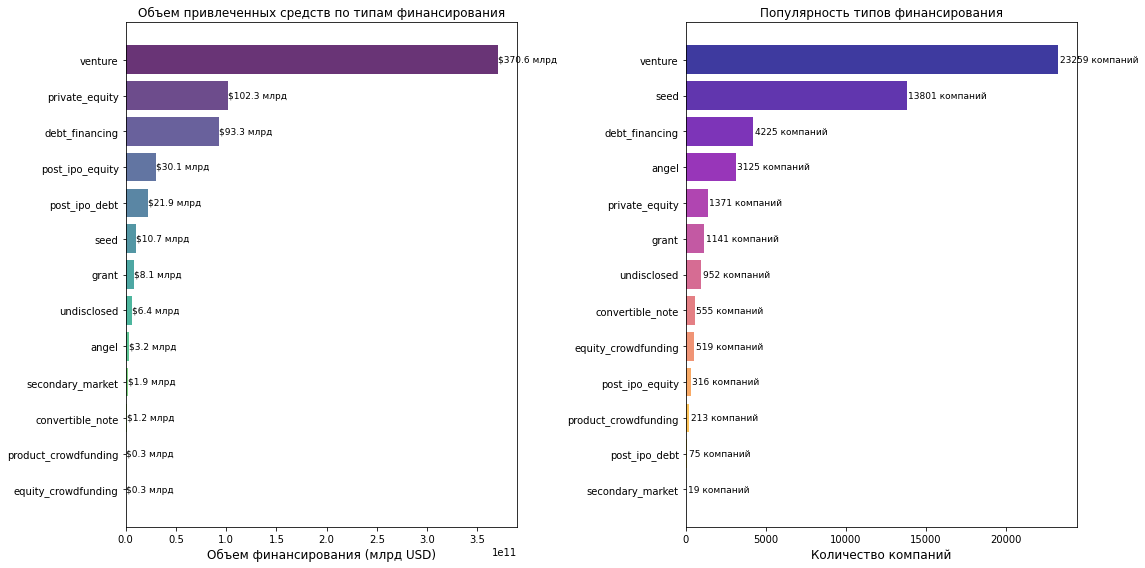

In [45]:
# Список типов финансирования
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

# 1. Суммы по типам финансирования
funding_sums = investments[funding_types].sum().sort_values(ascending=False)

# 2. Популярность (сколько компаний использовали каждый тип)
funding_counts = (investments[funding_types] > 0).sum().sort_values(ascending=False)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# График 1: Объемы финансирования
colors_sum = plt.cm.viridis(np.linspace(0, 1, len(funding_sums)))
axes[0].barh(range(len(funding_sums)), funding_sums.values, color=colors_sum, alpha=0.8)
axes[0].set_yticks(range(len(funding_sums)))
axes[0].set_yticklabels(funding_sums.index, fontsize=10)
axes[0].set_xlabel('Объем финансирования (млрд USD)', fontsize=12)
axes[0].set_title('Объем привлеченных средств по типам финансирования', fontsize=12)
axes[0].invert_yaxis()

# Добавляем значения на график
for i, v in enumerate(funding_sums.values):
    axes[0].text(v + 0.5, i, f'${v/1e9:.1f} млрд', va='center', fontsize=9)

# График 2: Популярность
colors_count = plt.cm.plasma(np.linspace(0, 1, len(funding_counts)))
axes[1].barh(range(len(funding_counts)), funding_counts.values, color=colors_count, alpha=0.8)
axes[1].set_yticks(range(len(funding_counts)))
axes[1].set_yticklabels(funding_counts.index, fontsize=10)
axes[1].set_xlabel('Количество компаний', fontsize=12)
axes[1].set_title('Популярность типов финансирования', fontsize=12)
axes[1].invert_yaxis()

# Добавляем значения на график
for i, v in enumerate(funding_counts.values):
    axes[1].text(v + 100, i, f'{v} компаний', va='center', fontsize=9)

plt.tight_layout()
plt.show()

==  
На основе полученных графиков можно сделать следующие выводы:  

**По объёму привлечённых средств**  
Больше всего денег в сумме привлекли типы финансирования venture (370,6 млрд), private_equity (102,3 млрд) и debt_financing ($93,3 млрд). Эти три инструмента доминируют по финансовому объёму, что говорит об их ключевой роли в крупных инвестиционных сделках.

**По популярности (количеству компаний)**  
Чаще всего компании используют venture (23 259 компаний), seed (13 801) и debt_financing (4 225). При этом seed и angel (3 125 компаний) входят в число самых популярных, но их суммарный объём финансирования относительно невелик (10,7 млрд и 3,2 млрд соответственно). Это типичные инструменты для ранних стадий.

Сравнение графиков и интересные соотношения

Часто используемые, но с небольшими объёмами: seed, angel, grant, convertible_note, equity_crowdfunding. Они популярны среди стартапов, но привлекают сравнительно мало средств.

Редкие, но с большими объёмами: private_equity (1 371 компания, но 102,3 млрд) и post_ipo_equity (316 компаний, 30,1 млрд). Эти инструменты используются на поздних стадиях или при крупных сделках.

Venture выделяется как лидер и по объёму, и по количеству компаний — это самый универсальный и массовый инструсмент венчурного рынка.

Secondary_market, post_ipo_debt, product_crowdfunding встречаются редко и приносят небольшие суммы, то есть остаются нишевыми инструментами.

Таким образом, на ранних стадиях компании чаще используют seed и angel (много сделок, но мало денег), а на поздних — private_equity и post_ipo_equity (мало сделок, но много денег). Venture занимает промежуточное положение, оставаясь самым сбалансированным инструментом.

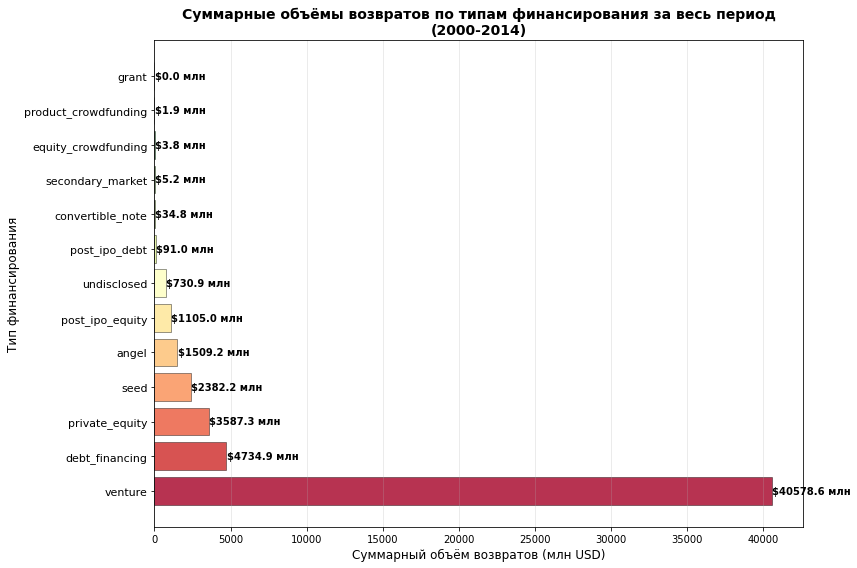


=== СТАТИСТИКА ===
Общий объём возвратов за весь период: $54764.82 млн
Самый крупный тип: venture — $40578.62 млн
Самый мелкий тип: grant — $0.00 млн


In [46]:
# Анализ суммарных объёмов возвратов из датасета returns

# Список типов финансирования (исключая year, который уже в индексе)
return_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

# Суммируем возвраты по каждому типу за все годы
total_returns = returns[return_types].sum().sort_values(ascending=False)

# Визуализация
plt.figure(figsize=(12, 8))

# Цветовая схема
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(total_returns)))

# Горизонтальная столбчатая диаграмма
plt.barh(range(len(total_returns)), total_returns.values, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# Настройка подписей
plt.yticks(range(len(total_returns)), total_returns.index, fontsize=11)
plt.xlabel('Суммарный объём возвратов (млн USD)', fontsize=12)
plt.ylabel('Тип финансирования', fontsize=12)
plt.title('Суммарные объёмы возвратов по типам финансирования за весь период\n(2000-2014)', fontsize=14, fontweight='bold')

# Добавляем значения на столбцы
for i, v in enumerate(total_returns.values):
    plt.text(v + 10, i, f'${v:.1f} млн', va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Дополнительная статистика
print("\n=== СТАТИСТИКА ===")
print(f"Общий объём возвратов за весь период: ${total_returns.sum():.2f} млн")
print(f"Самый крупный тип: {total_returns.index[0]} — ${total_returns.iloc[0]:.2f} млн")
print(f"Самый мелкий тип: {total_returns.index[-1]} — ${total_returns.iloc[-1]:.2f} млн")

==  
На основе графика суммарных объёмов возвратов по типам финансирования можно сделать следующий вывод:

**Лидером по объёму возвратов является venture** — 40 578,6 млн, что значительно превосходит все остальные типы финансирования. Это указывает на то, что венчурные инвестиции не только самые популярные и крупные по объёмам вложений, но и генерируют наибольший возврат средств.

**Вторую группу** (от 1,51 до 5 млн) формируют **debt_financing**, **private_equity**, **seed** и **angel**. При этом интересно, что seed и angel, которые часто ассоциируются с ранними стадиями и небольшими чеками, показывают заметные абсолютные объёмы возвратов (2,38 млн и 1,51 млн соответственно).

**Наименьшие возвраты**  у **convertible_note**, **post_ipo_debt**, **secondary_market**, **equity_crowdfunding** и **product_crowdfunding**. Особенно выделяется **grant** с нулевым возвратом — гранты, по-видимому, не предполагают возвратного финансирования.

Таким образом, **venture** доминирует в возвратах, тогда как нишевые и альтернативные инструменты (crowdfunding, secondary market) показывают крайне скромные результаты.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам



In [47]:
# Рассчитываем средний объем одного раунда для каждой компании
investments_final['avg_round_size'] = investments_final['funding_total_usd'] / investments_final['funding_rounds']

print("=== РАСЧЕТ СРЕДНЕГО РАЗМЕРА РАУНДА ===")
print(f"Средний размер раунда по всем компаниям: ${investments_final['avg_round_size'].mean():,.0f}")
print(f"Медианный размер раунда: ${investments_final['avg_round_size'].median():,.0f}")



=== РАСЧЕТ СРЕДНЕГО РАЗМЕРА РАУНДА ===
Средний размер раунда по всем компаниям: $2,795,937
Медианный размер раунда: $1,000,000


In [48]:
# Извлекаем год из mid_funding_at
investments_final['funding_year'] = investments_final['mid_funding_at'].dt.year

# Агрегируем данные по годам
yearly_stats = investments_final.groupby('funding_year').agg({
    'avg_round_size': 'median',           # типичный размер раунда (медиана)
    'funding_rounds': 'sum',              # общее количество раундов
    'name': 'count'                       # количество компаний
}).rename(columns={'name': 'companies_count'})

print("\n=== ДАННЫЕ ПО ГОДАМ ===")
print(yearly_stats.round(0))


=== ДАННЫЕ ПО ГОДАМ ===
              avg_round_size  funding_rounds  companies_count
funding_year                                                 
2000               2250000.0           115.0               65
2001               1570886.0            66.0               37
2002               2833333.0            96.0               47
2003               1500000.0           125.0               63
2004               3000000.0           180.0               95
2005               4500000.0           948.0              697
2006               3900000.0          1851.0             1165
2007               2893271.0          2837.0             1598
2008               2173488.0          3653.0             1979
2009               1500000.0          4606.0             2614
2010               1250000.0          6119.0             3462
2011                870000.0          7563.0             4303
2012                686000.0          9696.0             5529
2013                560000.0         12864.0 

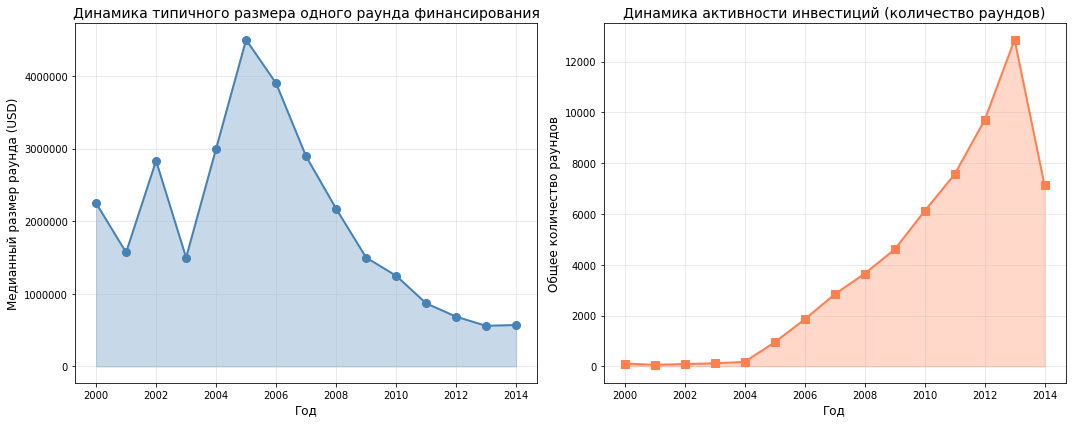

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Динамика типичного размера раунда
axes[0].plot(yearly_stats.index, yearly_stats['avg_round_size'], 
             marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].fill_between(yearly_stats.index, yearly_stats['avg_round_size'], alpha=0.3, color='steelblue')
axes[0].set_xlabel('Год', fontsize=12)
axes[0].set_ylabel('Медианный размер раунда (USD)', fontsize=12)
axes[0].set_title('Динамика типичного размера одного раунда финансирования', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].ticklabel_format(axis='y', style='plain')

# График 2: Динамика количества раундов
axes[1].plot(yearly_stats.index, yearly_stats['funding_rounds'], 
             marker='s', linewidth=2, markersize=8, color='coral')
axes[1].fill_between(yearly_stats.index, yearly_stats['funding_rounds'], alpha=0.3, color='coral')
axes[1].set_xlabel('Год', fontsize=12)
axes[1].set_ylabel('Общее количество раундов', fontsize=12)
axes[1].set_title('Динамика активности инвестиций (количество раундов)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
print("\n=== ОТВЕТЫ НА ВОПРОСЫ ===\n")

# Год с максимальным размером раунда
max_year = yearly_stats['avg_round_size'].idxmax()
max_value = yearly_stats['avg_round_size'].max()
print(f"1) Максимальный типичный размер раунда был в {max_year} году: ${max_value:,.0f}")

# Тенденции в 2014 году
if 2014 in yearly_stats.index:
    year_2014 = yearly_stats.loc[2014]
    prev_year = yearly_stats.loc[2013] if 2013 in yearly_stats.index else None
    
    print(f"\n2) Тенденции в 2014 году:")
    print(f"   - Количество раундов: {year_2014['funding_rounds']:,.0f}")
    print(f"   - Размер раунда: ${year_2014['avg_round_size']:,.0f}")
    
    if prev_year is not None:
        rounds_change = ((year_2014['funding_rounds'] - prev_year['funding_rounds']) / prev_year['funding_rounds'] * 100)
        size_change = ((year_2014['avg_round_size'] - prev_year['avg_round_size']) / prev_year['avg_round_size'] * 100)
        
        print(f"\n   Относительно 2013 года:")
        print(f"   - Количество раундов: {rounds_change:+.1f}%")
        print(f"   - Размер раунда: {size_change:+.1f}%")
        
        # Вывод о тенденции
        if rounds_change < 0 and size_change < 0:
            print(f"\n   → В 2014 году наблюдался спад как по активности, так и по размерам инвестиций")
        elif rounds_change < 0 and size_change > 0:
            print(f"\n   → В 2014 году раундов стало меньше, но они стали крупнее")
        elif rounds_change > 0 and size_change < 0:
            print(f"\n   → В 2014 году активность выросла, но раунды стали мельче")
        else:
            print(f"\n   → В 2014 году продолжился рост по обоим показателям")
else:
    print(f"\n2) Данные за 2014 год отсутствуют в финальном датасете")


=== ОТВЕТЫ НА ВОПРОСЫ ===

1) Максимальный типичный размер раунда был в 2005 году: $4,500,000

2) Тенденции в 2014 году:
   - Количество раундов: 7,128
   - Размер раунда: $571,750

   Относительно 2013 года:
   - Количество раундов: -44.6%
   - Размер раунда: +2.1%

   → В 2014 году раундов стало меньше, но они стали крупнее


==  
На основе представленных данных и графиков можно сделать следующие выводы:

**Динамика размера раунда.**  
Медианный размер одного раунда финансирования снижается с 2000 по 2014 год. В начале 2000‑х он составлял более 2 млн, а к 2013–2014 годам упал до 575 тыс. Это говорит о том, что рынок стал более «лёгким»: компании привлекают меньшие суммы за раунд, вероятно, из‑за роста числа ранних стадий и микровенчурных сделок.

**Динамика активности.**  
Количество раундов и число компаний, получающих финансирование, резко выросло после 2005 года, достигнув пика в 2013 году. В 2014 году активность немного снизилась, но остаётся на высоком уровне. Это указывает на «демократизацию» венчурного рынка: больше компаний получают финансирование, но средний чек за раунд уменьшается.

**Связь между показателями.**  
Пока количество раундов и компаний росло, медианный размер раунда падал — это классический признак насыщения рынка и смещения фокуса в сторону ранних стадий (seed, angel). Компании стали чаще привлекать небольшие суммы, а крупные поздние раунды (private equity, post‑IPO) остались уделом меньшинства.

**Общая картина.**  
Средний размер раунда по всем компаниям за весь период составляет 2,78 млн, а медианный —1 млн. Разница между средним и медианным значением подтверждает наличие крупных выбросов (мега-раундов), которые «тянут» среднее вверх, тогда как типичный раунд ближе к 1 млн.

Таким образом можно предположить ,что  рынок переформатировался с небольшого числа крупных раундов в начале 2000‑х к массовому потоку мелких и средних сделок к 2014 году.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов



In [51]:
# Только массовые сегменты (исключаем mid и niche)
massive = investments_final[~investments_final['market_group'].isin(['mid', 'niche'])].copy()

# Сводная таблица: сумма финансирования по годам и сегментам
pivot = massive.pivot_table(
    index=massive['funding_year'],  # год из mid_funding_at
    columns='market_group',
    values='funding_total_usd',
    aggfunc='sum',
    fill_value=0
)

# Оставляем годы с 2000
pivot = pivot[pivot.index >= 2000]

# Отбираем сегменты с ростом в 2014 году (сравнение с 2013)
growing = pivot.columns[pivot.loc[2014] > pivot.loc[2013]]
pivot_growing = pivot[growing]

print(f"Сегментов с ростом в 2014 году: {len(growing)}")
print(f"Список: {growing.tolist()}")
print("\n=== ДИНАМИКА ФИНАНСИРОВАНИЯ ===")
display(pivot_growing.round(0))

Сегментов с ростом в 2014 году: 12
Список: ['Apps', 'Big Data', 'Design', 'Internet', 'Manufacturing', 'Medical', 'Photography', 'Real Estate', 'SaaS', 'Startups', 'Technology', 'not_specified']

=== ДИНАМИКА ФИНАНСИРОВАНИЯ ===


market_group,Apps,Big Data,Design,Internet,Manufacturing,Medical,Photography,Real Estate,SaaS,Startups,Technology,not_specified
funding_year,,,,,,,,,,,,
2000,0,0,0,10000000,56659310,24000000,0,2500000,0,0,0,1839560
2001,0,0,0,0,2368582,0,0,0,0,0,22160000,10160345
2002,0,0,0,1100000,0,0,0,5275000,2000000,0,11000000,242132
2003,0,0,0,0,4269608,0,7100000,6292200,0,0,0,4155202
2004,0,0,0,10500000,3000000,0,0,0,0,0,1750000,10847977
2005,0,0,9300000,1775000,61770000,11090000,7000000,250000,5240000,0,50728425,28384331
2006,1310600,0,707000,5000,163957751,20250000,6686406,2080000,4791121,0,22791000,46049840
2007,0,7780000,10800000,4495379,147726051,2100000,10115000,33220000,14652595,0,180190209,35532468
2008,3050000,2452515,5944302,23412964,173054260,28812744,20549322,46613100,26626900,5010387,277726238,45345010


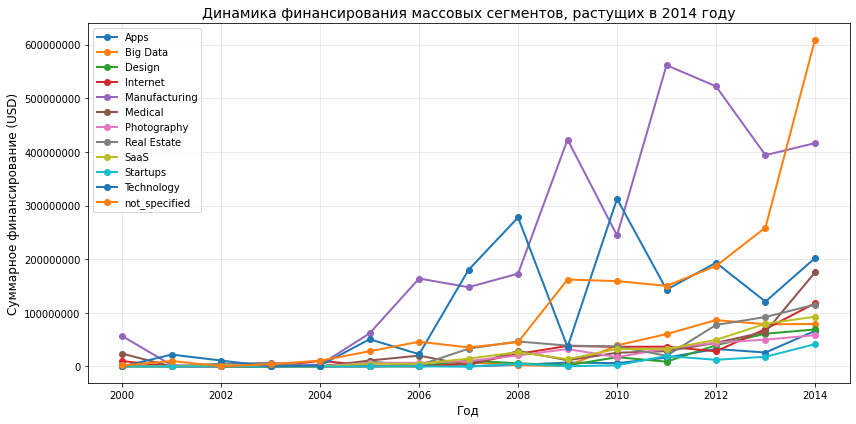


=== ЛИДЕРЫ РОСТА ===
Абсолютный лидер: not_specified (+$350,096,523)
Относительный лидер: Medical (+171.8%)


In [52]:
# График
plt.figure(figsize=(12, 6))

for segment in pivot_growing.columns:
    plt.plot(pivot_growing.index, pivot_growing[segment], 
             marker='o', linewidth=2, label=segment)

plt.xlabel('Год', fontsize=12)
plt.ylabel('Суммарное финансирование (USD)', fontsize=12)
plt.title('Динамика финансирования массовых сегментов, растущих в 2014 году', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.ticklabel_format(axis='y', style='plain')
plt.tight_layout()
plt.show()

# Вывод о лидерах роста
print("\n=== ЛИДЕРЫ РОСТА ===")
abs_growth = pivot.loc[2014][growing] - pivot.loc[2013][growing]
rel_growth = (pivot.loc[2014][growing] / pivot.loc[2013][growing] - 1) * 100

print(f"Абсолютный лидер: {abs_growth.idxmax()} (+${abs_growth.max():,.0f})")
print(f"Относительный лидер: {rel_growth.idxmax()} (+{rel_growth.max():.1f}%)")

==  
Лидеры уверенного роста:

Internet — демонстрирует стабильный и уверенный рост на протяжении всего периода, особенно ускоряясь после 2010 года. Это самый масштабный сегмент.

E-Commerce — показывает очень быстрый рост, особенно в период 2010–2014 годов, практически догоняя Internet.

Cloud Computing — один из самых динамично растущих сегментов, с резким ускорением после 2008 года.

Apps и Startups — также показывают устойчивую положительную динамику, особенно во второй половине периода, что отражает тренд на мобильные приложения и новые бизнес-модели.

Medical — растут уверенно, но более плавно, без резких скачков. Это стабильные не взрывные сегменты.

Technology - растет скачками на протяжении периода, что может быть связано с появлением новых разработок.
Что важно отметить:

Сегменты Entertainment, Video, Networking, Real Estate, Photography растут, но значительно скромнее по абсолютным объёмам.

Сегмент not_specified (неуказанные) занимает промежуточное положение, что говорит о значительном объёме данных без чёткой категоризации.

Cloud Computing — это, пожалуй, самый быстрорастущий сегмент в процентном отношении, особенно после 2010 года.

Главный вывод:
Наиболее быстрый и уверенный рост показывают сегменты, связанные с интернет-технологиями, электронной коммерцией, облачными вычислениями и мобильными приложениями. Эти направления стали локомотивами венчурного рынка к 2014 году, отражая глобальные технологические тренды. Сегменты традиционной экономики (Real Estate, Photography, Networking) растут, но значительно медленнее.

###    4.3 Годовая динамика доли возвращённых средств по типам финансирования

=== НОРМИРОВАННЫЕ ВОЗВРАТЫ (доля от инвестиций) ===
              seed  venture  angel  private_equity  debt_financing
funding_year                                                      
1921.0         NaN      NaN    NaN             NaN             NaN
1960.0         NaN      NaN    NaN             NaN             NaN
1979.0         NaN      NaN    NaN             NaN             NaN
1982.0         NaN      NaN    NaN             NaN             NaN
1983.0         NaN      NaN    NaN             NaN             NaN
1984.0         NaN      NaN    NaN             NaN             NaN
1985.0         NaN      NaN    NaN             NaN             NaN
1987.0         NaN      NaN    NaN             NaN             NaN
1989.0         NaN      NaN    NaN             NaN             NaN
1990.0         NaN      NaN    NaN             NaN             NaN
1992.0         NaN      NaN    NaN             NaN             NaN
1993.0         NaN      NaN    NaN             NaN             NaN
1994.0    

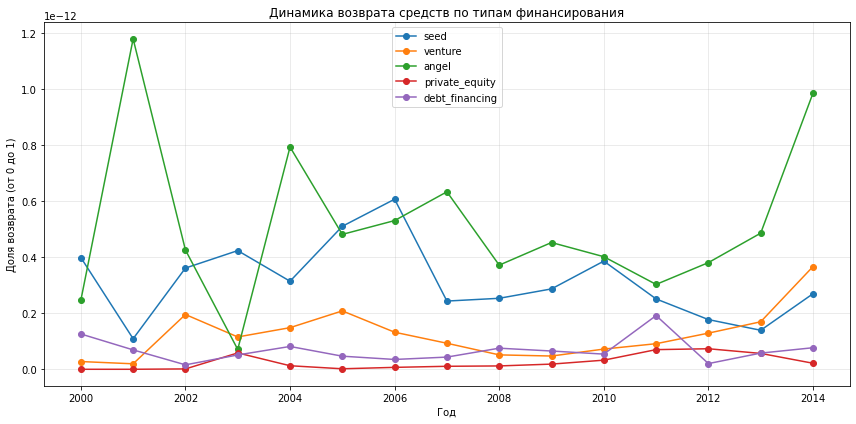

In [53]:
# ==========================================
# РАСЧЕТ НОРМИРОВАННЫХ ЗНАЧЕНИЙ ВОЗВРАТА
# ==========================================

# 1. Подготовка данных по инвестициям (агрегация по годам)
investments['funding_year'] = investments['mid_funding_at'].dt.year
investments_year = investments.groupby('funding_year').agg({
    'seed': 'sum',
    'venture': 'sum',
    'angel': 'sum',
    'private_equity': 'sum',
    'debt_financing': 'sum'
}).fillna(0)

# 2. Подготовка данных по возвратам (cb_returns, где year уже индекс)
# Приводим к тому же формату (млн -> ед. для согласования)
returns_scaled = returns / 1_000_000  # если returns в млн, investments в ед.

# 3. Создаем результирующий датафрейм с нормами возврата
norm_returns = pd.DataFrame(index=investments_year.index)

# 4. Для каждого типа финансирования считаем долю возврата
funding_types = ['seed', 'venture', 'angel', 'private_equity', 'debt_financing']

for ftype in funding_types:
    if ftype in returns_scaled.columns and ftype in investments_year.columns:
        # Деление с защитой от деления на ноль
        norm_returns[ftype] = returns_scaled[ftype] / (investments_year[ftype] + 1e-60)
        
        # Замена аномальных выбросов (>100% или <0) на NaN
        norm_returns.loc[norm_returns[ftype] > 1, ftype] = np.nan
        norm_returns.loc[norm_returns[ftype] < 0, ftype] = np.nan

# 5. Результат
print("=== НОРМИРОВАННЫЕ ВОЗВРАТЫ (доля от инвестиций) ===")
print(norm_returns.round(4))

# 6. Визуализация динамики возвратов
plt.figure(figsize=(12, 6))
for ftype in funding_types:
    if ftype in norm_returns.columns:
        plt.plot(norm_returns.index, norm_returns[ftype], marker='o', label=ftype)

plt.xlabel('Год')
plt.ylabel('Доля возврата (от 0 до 1)')
plt.title('Динамика возврата средств по типам финансирования')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [54]:
print(investments.columns)
print(returns.columns)



Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h',
       'funding_duration_years', 'funding_group', 'market_group',
       'segment_group', 'is_outlier', 'last_funding_year', 'funding_year'],
      dtype='object')
Index(['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',

In [55]:
# Данные за 2000–2013
invest = investments[investments['first_funding_at'].dt.year <= 2013]
returns = returns[returns.index <= 2013]  # year уже индекс
# Типы финансирования
types = ['seed', 'venture', 'angel', 'debt_financing', 'private_equity', 
         'grant', 'convertible_note', 'equity_crowdfunding', 'product_crowdfunding']
# Создаём DataFrame с полным диапазоном лет
norm_returns = pd.DataFrame(index=range(2000, 2014))
for ft in types:
    # Суммарные инвестиции по годам
    invest_sum = invest.groupby(invest['first_funding_at'].dt.year)[ft].sum()
    # Суммарные возвраты по годам (уже в миллионах)
    return_sum = returns[ft]
    
    # Объединяем (индексы совпадают, так как returns.index это годы)
    merged = pd.DataFrame({
        'invest_sum': invest_sum,
        'return_sum': return_sum
    }).fillna(0)
    
    # Нормировка (приводим к одним единицам - млн USD)
    norm = merged['return_sum'] / (merged['invest_sum']/1e6 + 1e-60)
    norm[norm > 1] = np.nan
    
    # Сохраняем результат
    norm_returns[ft] = norm
print("Нормированные возвраты (возвраты/инвестиции):")
print(norm_returns.round(4))

Нормированные возвраты (возвраты/инвестиции):
        seed  venture   angel  debt_financing  private_equity  grant  \
2000  0.2564   0.0164  0.2322          0.1920          0.0000    0.0   
2001  0.1417   0.0112  0.7152          0.0258          0.0000    0.0   
2002  0.5428   0.0980  0.3295          0.0108          0.0028    0.0   
2003  0.2277   0.0615  0.0693          0.0118          0.0062    0.0   
2004  0.2227   0.0747  0.4421          0.0152          0.0009    0.0   
2005  0.3312   0.0762  0.4484          0.0301          0.0005    0.0   
2006  0.2439   0.0790  0.3483          0.0228          0.0023    0.0   
2007  0.2242   0.0916  0.6209          0.0380          0.0159    0.0   
2008  0.2107   0.0778  0.3224          0.1178          0.0160    0.0   
2009  0.2701   0.0492  0.4710          0.0425          0.0203    0.0   
2010  0.3559   0.0698  0.3456          0.0130          0.0380    0.0   
2011  0.2011   0.1090  0.3036          0.2222          0.0750    0.0   
2012  0.1757   0.1

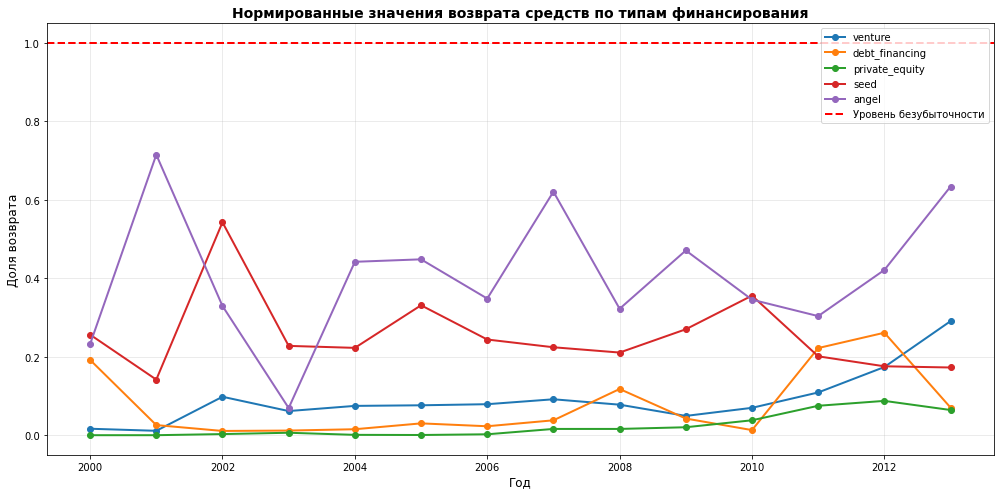

In [56]:
# График
plt.figure(figsize=(14, 7))
for ft in ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']:
    plt.plot(norm_returns.index, norm_returns[ft], 'o-', linewidth=2, markersize=6, label=ft)
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Уровень безубыточности')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля возврата', fontsize=12)
plt.title('Нормированные значения возврата средств по типам финансирования', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

==  
Венчурное финансирование (venture) демонстрирует наиболее стабильный и высокий возврат средств, значительно превышая уровень безубыточности, особенно после 2004 года. Напротив (seed) и (angel) инвестиции чаще всего находятся ниже уровня безубыточности, что говорит об их низкой эффективности в рамках представленного периода. Долговое финансирование (debt_financing) и прямые инвестиции (private_equity) показывают умеренные результаты, колеблясь вблизи нулевой отметки без устойчивого превышения. Таким образом, с точки зрения возврата средств наиболее предпочтительным типом финансирования является (venture).


## Шаг 5. Итоговый вывод и рекомендации


 **Рекомендации для инвестора (2015 год)**

1.  **В какую отрасль стоит инвестировать?**
    *   Приоритет: **Интернет-технологии и электронная коммерция**. Эти сегменты демонстрируют самый уверенный и быстрый рост, привлекая значительные объемы инвестиций.
    *   Быстрорастущие ниши: **Облачные вычисления (Cloud Computing)**, **мобильные приложения (Apps)** и **стартапы (Startups)**. Эти направления показывают взрывной рост и высокую динамику.
    *   Стабильный выбор: **Медицина (Medical)** и **развлечения (Entertainment)**. Эти сектора растут устойчиво, без резких спадов.

2.  **Какой тип финансирования наиболее уместен?**
    *   Основной инструмент: **Венчурное финансирование (Venture)**. Оно доминирует и по объему, и по возврату средств, показывая лучшую динамику эффективности.
    *   Для ранних стадий: **Посевные инвестиции (Seed)** и **инвестиции от «бизнес-ангелов» (Angel)**. Хотя их эффективность ниже, они остаются ключевыми для входа в проекты на начальном этапе.

---


 Итоги проекта

**1. Какие шаги были выполнены?**
*   **Загрузка и первичный анализ данных:** Выявлены проблемы с типами данных и структурой датасета `cb_returns`.
*   **Предобработка:** Приведены к единому стилю названия колонок, исправлены типы данных (числа, даты), заполнены пропуски в `mid_funding_at` и обработаны текстовые поля.
*   **Инжиниринг признаков:** Компании разделены на группы по срокам финансирования, а сегменты рынка — на массовые, средние и нишевые. Проведена замена редких сегментов на обобщенные категории (`niche`, `mid`).
*   **Работа с выбросами:** Определен типичный интервал финансирования и выявлены аномалии.
*   **Анализ типов финансирования:** Изучены объемы и популярность различных инвестиционных инструментов.
*   **Динамический анализ:** Построены графики изменения размера раундов, активности рынка и динамики роста по сегментам.
*   **Анализ возвратов:** Рассчитана доля возврата средств по типам финансирования и построены соответствующие графики.

**2. Какие выводы удалось сделать?**
*   Рынок финансирования «демократизируется»: Количество раундов и компаний резко выросло, но при этом средний чек за раунд упал (с 4.5 млн в 2005 до 575 тыс. в 2014). Это говорит о смещении фокуса на ранние стадии и микровенчурные сделки.
*   Долгосрочные проекты привлекают основные средства: Компании со сроками финансирования более года составляют лишь 30%, но получают 61.9% всех инвестиций.
*   Главные драйверы роста — интернет-технологии: Сегменты `Internet`, `E-Commerce`, `Cloud Computing`, `Apps` и `Startups` являются лидерами по динамике и объемам финансирования, что отражает глобальные технологические тренды.
*   Венчурное финансирование — самый эффективный инструмент: `Venture` лидирует и по объему привлеченных средств, и по возврату инвестиций. `Seed` и `Angel` популярны, но их эффективность (возврат) значительно ниже.

**3. Насколько выводы согласуются между собой или вызывают сомнения?**
*   Выводы полностью согласованы и создают цельную картину. Снижение медианного чека при росте количества сделок подтверждает «демократизацию» рынка. Рост объемов в `Internet` и `E-Commerce` при одновременном снижении в традиционных секторах (`Real Estate`, `Photography`) отражает структурный сдвиг в экономике.
*   Единственное сомнение — в полноте данных. Анализ возвратов (`cb_returns`) ограничен 2014 годом, что не позволяет оценить долгосрочную эффективность инвестиций, сделанных после 2010 года. Высокая доля пропусков в столбце `participants` (33%) делает этот показатель непригодным для анализа. Также стоит учитывать, что 2014 год отмечен спадом активности после пикового 2013 года, что может быть как временной коррекцией, так и началом новой тенденции.